In [1]:
import pandas as pd # For DataFrames, Series, and reading csv data in.
import seaborn as sns # Graphing, built ontop of MatPlot for ease-of-use and nicer diagrams.
import matplotlib.pyplot as plt # MatPlotLib for graphing data visually. Seaborn more likely to be used.
import numpy as np # For manipulating arrays and changing data into correct formats for certain libraries
from sklearn.model_selection import train_test_split
%matplotlib inline
from sklearn.preprocessing import StandardScaler  # For Normalization
import scikitplot # Confusion matrix plotting

In [2]:
df1=pd.read_csv('data/Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv')
#df1=df1.sample(n=100000,random_state=24)
df2 = pd.read_csv('data/Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv')
#df2=df2.sample(n=100000,random_state=24)
df3 = pd.read_csv('data/Friday-WorkingHours-Morning.pcap_ISCX.csv')
#df3=df3.sample(n=100000,random_state=24)
df4 = pd.read_csv('data/Monday-WorkingHours.pcap_ISCX.csv')
#df4=df4.sample(n=100000,random_state=24)
df5 = pd.read_csv('data/Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv')
#df5=df5.sample(n=100000,random_state=24)
df6 = pd.read_csv('data/Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv')
#df6=df6.sample(n=100000,random_state=24)
df7 = pd.read_csv('data/Tuesday-WorkingHours.pcap_ISCX.csv')
#df7=df7.sample(n=100000,random_state=24)
df8 = pd.read_csv('data/Wednesday-workingHours.pcap_ISCX.csv')
#df8=df8.sample(n=100000,random_state=24)


In [3]:
df=pd.concat([df1,df2,df3,df4,df5,df6,df7,df8],axis=0)
del df1,df2,df3,df4,df5,df6,df7,df8

In [4]:
df.columns = df.columns.str.strip().str.lower().str.replace(' ', '_').str.replace('(', '').str.replace(')', '')
#handling nan and inf values
def clean_dataset(df_cleaned):
    assert isinstance(df_cleaned, pd.DataFrame), "df needs to be a pd.DataFrame"
    df_cleaned.dropna(inplace=True) #eliminating rows or columns containing NaN values.
    indices_to_keep = ~df_cleaned.isin([np.nan, np.inf, -np.inf]).any(axis=1)
    return df_cleaned[indices_to_keep].astype(np.float64)


df_cleaned = df.copy()
#.reset_index() method resets the Pandas Dataframe indexes, for the rows. Useful to do after merging rows, as this messes up the indexes.
df_cleaned = df_cleaned.reset_index()
df_cleaned.drop('index', axis=1, inplace=True)
from sklearn.preprocessing import LabelEncoder
Le=LabelEncoder()
'''
df_cleaned['label'] = df_cleaned['label'].replace({'BENIGN': 0, 'DDoS': 1 ,'PortScan':2, 'Bot':3,'Infiltration':4,'Web Attack � Brute Force':5,'Web Attack � XSS':6,
                       ValueError: Found input variables with inconsistent numbers of samples: [2262300, 565576]                            'Web Attack � Sql Injection':7,'FTP-Patator':8,'SSH-Patator':9,'DoS slowloris':10,'DoS Slowhttptest':11,'DoS Hulk':12,'DoS GoldenEye':13,'Heartbleed':14})
'''
df_cleaned['label']=Le.fit_transform(df_cleaned['label'])
Le.classes_
#for inverse transform
#Le.inverse_transform([number])


array(['BENIGN', 'Bot', 'DDoS', 'DoS GoldenEye', 'DoS Hulk',
       'DoS Slowhttptest', 'DoS slowloris', 'FTP-Patator', 'Heartbleed',
       'Infiltration', 'PortScan', 'SSH-Patator',
       'Web Attack � Brute Force', 'Web Attack � Sql Injection',
       'Web Attack � XSS'], dtype=object)

In [5]:
df_cleaned = clean_dataset(df_cleaned)


In [6]:
def Pre_process_data(df,col):
    '''
    input data-frame and coumn name
    operation fills the nan values with the minimum value in thier respective colum
    output returns the pre-processed dataframe
    '''
    print("Name of column with NaN:"+str(col))
    print(df[col].value_counts(dropna=False,normalize=True).head())
    df[col].replace(np.inf,-1,inplace=True)
    return df

In [7]:
def reduce_mem_usage(df):
    '''
    
   
    '''
    #print("Memory usage of properties dataframe is:", df.memory_usage().sum()/1024**2, "MB")
    for col in df.columns:
        if df[col].dtype != object: #exclude strings
            print("***************************************")
            print("Column:", col)
            print("dtype before:", df[col].dtype)
            # make variables for int, max and min
            IsInt = False
            mx = df[col].max
            mn = df[col].min
            # NA values should be handled prior to this
            if not np.isfinite(df[col].all()):
                df=Pre_process_data(df,col)
                
            asint = df[col].fillna(0).astype(np.int64)
            result = (df[col] - asint)
            result = result.sum()
            if result > -0.01 and result < 0.01:
                IsInt=True
            
            if IsInt:
                if mn() >= 0:
                    if mx() < 255:
                        df[col] = df[col].astype(np.uint8)
                    elif mx() < 65535:
                        df[col] = df[col].astype(np.uint16)
                    elif mx() < 4294967295:
                        df[col] = df[col].astype(np.uint32)
                    else:
                        df[col] = df[col].astype(np.uint64)
                else:
                    if mn() > np.iinfo(np.int8).min and mx() < np.iinfo(np.int8).max:
                        df[col] = df[col].astype(np.int8)
                    elif mn() > np.iinfo(np.int16).min and mx() < np.iinfo(np.int16).max:
                        df[col] = df[col].astype(np.int16)
                    elif mn() > np.iinfo(np.int32).min and mx() < np.iinfo(np.int32).max:
                        df[col] = df[col].astype(np.int32)
                    elif mn() > np.iinfo(np.int64).min and mx() < np.iinfo(np.int64).max:
                        df[col] = df[col].astype(np.int64)
            # make float datatypes 32bit
            else:
                df[col] = df[col].astype(np.float32)

          # print new column type
        print("dtype after:", df[col].dtype)
        print("*********************")
                
    #print("mem usage after completion")
    #mem_usg = df.memory_usage().sum / 1024 ** 2
   # print("final memory usage",mem_usg, "MB")
    return df

In [8]:
df_cleaned=reduce_mem_usage(df_cleaned) 

***************************************
Column: destination_port
dtype before: float64
dtype after: uint32
*********************
***************************************
Column: flow_duration
dtype before: float64
dtype after: int32
*********************
***************************************
Column: total_fwd_packets
dtype before: float64
dtype after: uint32
*********************
***************************************
Column: total_backward_packets
dtype before: float64
dtype after: uint32
*********************
***************************************
Column: total_length_of_fwd_packets
dtype before: float64
dtype after: uint32
*********************
***************************************
Column: total_length_of_bwd_packets
dtype before: float64
dtype after: uint32
*********************
***************************************
Column: fwd_packet_length_max
dtype before: float64
dtype after: uint16
*********************
***************************************
Column: fwd_packet_length_m

In [9]:
df_cleaned['label'].value_counts()

label
0     2271320
4      230124
10     158804
2      128025
3       10293
7        7935
11       5897
6        5796
5        5499
1        1956
12       1507
14        652
9          36
13         21
8          11
Name: count, dtype: int64

In [10]:
%matplotlib inline
X=df_cleaned.drop('label',axis=1)
y=df_cleaned['label']

In [11]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=24)

In [12]:
corr_features={'fwd_iat_std','flow_iat_min','packet_length_variance','idle_min','fwd_psh_flags', 'bwd_psh_flags',
       'fwd_urg_flags', 'bwd_urg_flags', 'fwd_header_length','fin_flag_count',
       'syn_flag_count', 'rst_flag_count', 'psh_flag_count', 'ack_flag_count',
       'urg_flag_count', 'cwe_flag_count', 'ece_flag_count', 'down/up_ratio',
       'average_packet_size', 'avg_fwd_segment_size', 'avg_bwd_segment_size',
       'fwd_header_length.1', 'fwd_avg_bytes/bulk', 'fwd_avg_packets/bulk',
       'fwd_avg_bulk_rate', 'bwd_avg_bytes/bulk', 'bwd_avg_packets/bulk',
       'bwd_avg_bulk_rate', 'subflow_fwd_packets', 'subflow_fwd_bytes',
       'subflow_bwd_packets', 'subflow_bwd_bytes', 'init_win_bytes_forward','init_win_bytes_backward', 'act_data_pkt_fwd', 'min_seg_size_forward',
       'active_mean', 'active_std', 'active_max', 'active_min', 'idle_mean',
       'idle_std', 'idle_max', 'idle_min','destination_port','bwd_header_length'}

In [13]:
X_train.drop(corr_features,axis=1,inplace=True) #exporting does not preserve datatype hence increases size of file
X_test.drop(corr_features,axis=1,inplace=True)


In [14]:
sc=StandardScaler()
X_train.iloc[:,:]=sc.fit_transform(X_train.iloc[:,:]) #Must have equal len keys and value when setting with a ndarray
X_test.iloc[:,:]=sc.transform(X_test.iloc[:,:])

In [15]:
X_train=reduce_mem_usage(X_train)
X_test=reduce_mem_usage(X_test)


***************************************
Column: flow_duration
dtype before: float64
dtype after: float32
*********************
***************************************
Column: total_fwd_packets
dtype before: float64
dtype after: float32
*********************
***************************************
Column: total_backward_packets
dtype before: float64
dtype after: float32
*********************
***************************************
Column: total_length_of_fwd_packets
dtype before: float64
dtype after: float32
*********************
***************************************
Column: total_length_of_bwd_packets
dtype before: float64
dtype after: float32
*********************
***************************************
Column: fwd_packet_length_max
dtype before: float64
dtype after: float32
*********************
***************************************
Column: fwd_packet_length_min
dtype before: float64
dtype after: float32
*********************
***************************************
Column: fwd_pa

In [16]:
print(X_train.shape)
print(y_train.shape)
print(X_test.shape)
print(y_test.shape)

(2262300, 33)
(2262300,)
(565576, 33)
(565576,)


In [17]:
import keras
from keras import Sequential
from keras.layers import Dense,Dropout,Activation
from keras.optimizers import Adam


2024-01-13 09:25:52.267748: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2024-01-13 09:25:52.267821: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2024-01-13 09:25:52.350658: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2024-01-13 09:25:52.512808: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2024-01-13 09:25:53.796849: W tensorflow/compiler/tf2

In [18]:
model=Sequential([
    Dense(units=64,activation='relu'),
    Dense(units=32,activation='relu'),
    Dense(units=15,activation='softmax') #output layer  
])
model.compile(optimizer=Adam(),loss='sparse_categorical_crossentropy',metrics=['accuracy'])


2024-01-13 09:25:58.856478: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:901] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2024-01-13 09:25:59.134587: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:901] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2024-01-13 09:25:59.134884: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:901] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-

In [19]:
print(X_train.shape)
print(y_train.shape)
print(X_test.shape)
print(y_test.shape)

(2262300, 33)
(2262300,)
(565576, 33)
(565576,)


In [42]:
y_train.head(20)

671365     0
200368     0
2251023    4
614744     0
1214450    0
827942     0
1026786    0
1711181    7
1414781    0
518864     0
1912690    0
461074     0
1430368    0
1666613    0
1793516    0
463791     0
153635     2
911702     0
921537     0
838488     0
Name: label, dtype: uint8

In [20]:
history=model.fit(X_train,y_train,epochs=100,batch_size=50000,validation_data=(X_test, y_test))

2024-01-13 09:26:07.773346: W external/local_tsl/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 298623600 exceeds 10% of free system memory.
2024-01-13 09:26:08.069277: W external/local_tsl/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 298623600 exceeds 10% of free system memory.


Epoch 1/100


2024-01-13 09:26:09.625522: I external/local_xla/xla/service/service.cc:168] XLA service 0x7f5f88368a40 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2024-01-13 09:26:09.625567: I external/local_xla/xla/service/service.cc:176]   StreamExecutor device (0): NVIDIA GeForce GTX 1050 Ti, Compute Capability 6.1
2024-01-13 09:26:09.643513: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2024-01-13 09:26:09.682827: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:454] Loaded cuDNN version 8904
I0000 00:00:1705117269.790142   34165 device_compiler.h:186] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


46/46 [==============================] - 3s 21ms/step - loss: 1.6253 - accuracy: 0.6840 - val_loss: 0.7076 - val_accuracy: 0.8691
Epoch 2/100
46/46 [==============================] - 1s 16ms/step - loss: 0.5701 - accuracy: 0.8709 - val_loss: 0.4821 - val_accuracy: 0.8728
Epoch 3/100
46/46 [==============================] - 1s 16ms/step - loss: 0.4473 - accuracy: 0.8728 - val_loss: 0.4193 - val_accuracy: 0.8734
Epoch 4/100
46/46 [==============================] - 1s 16ms/step - loss: 0.4008 - accuracy: 0.8735 - val_loss: 0.3838 - val_accuracy: 0.8744
Epoch 5/100
46/46 [==============================] - 1s 16ms/step - loss: 0.3693 - accuracy: 0.8748 - val_loss: 0.3555 - val_accuracy: 0.8758
Epoch 6/100
46/46 [==============================] - 1s 16ms/step - loss: 0.3439 - accuracy: 0.8760 - val_loss: 0.3319 - val_accuracy: 0.8777
Epoch 7/100
46/46 [==============================] - 1s 15ms/step - loss: 0.3222 - accuracy: 0.8813 - val_loss: 0.3117 - val_accuracy: 0.8868
Epoch 8/100
46/46 

In [21]:
acc=model.evaluate(X_test,y_test,batch_size=50000)

12/12 [==============================] - 0s 7ms/step - loss: 0.0864 - accuracy: 0.9656


In [22]:
import joblib
joblib.dump(model, 'NN_model')

['NN_model']

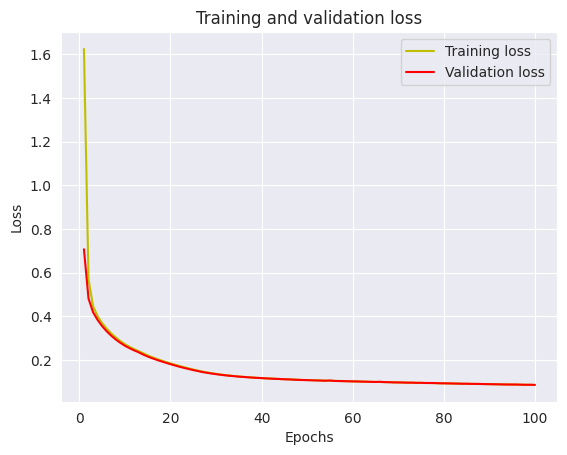

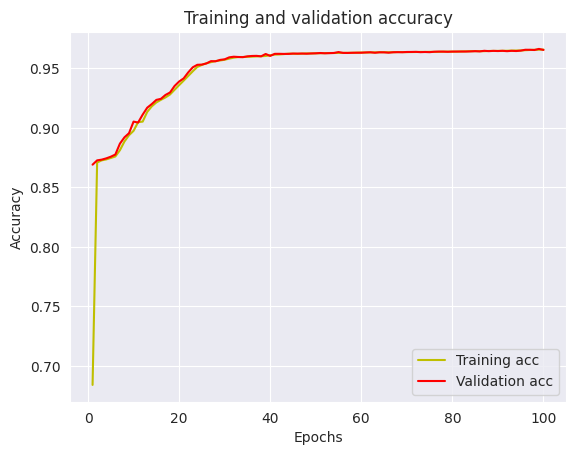

In [23]:
import matplotlib.pyplot as plt
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs = range(1, len(loss) + 1)
plt.plot(epochs, loss, 'y', label='Training loss')
plt.plot(epochs, val_loss, 'r', label='Validation loss')
plt.title('Training and validation loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()


acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
plt.plot(epochs, acc, 'y', label='Training acc')
plt.plot(epochs, val_acc, 'r', label='Validation acc')
plt.title('Training and validation accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

In [29]:
ytest_p=model.predict(X_test)
from sklearn.metrics import classification_report
#print(classification_report(y_test, ytest_p))

17675/17675 [==============================] - 22s 1ms/step


In [41]:
max_values_and_indices_per_row = [(np.max(row), np.argmax(row)) for row in ytest_p]
max_values_per_row, column_indices_max_per_row = zip(*max_values_and_indices_per_row)
column_indices_max_per_row

(0,
 0,
 0,
 4,
 2,
 4,
 0,
 2,
 0,
 0,
 4,
 0,
 0,
 3,
 0,
 10,
 0,
 2,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 4,
 0,
 0,
 0,
 0,
 0,
 0,
 4,
 0,
 0,
 4,
 0,
 0,
 0,
 0,
 0,
 2,
 10,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 4,
 0,
 10,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 2,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 4,
 0,
 4,
 0,
 0,
 10,
 0,
 0,
 0,
 0,
 0,
 0,
 10,
 0,
 0,
 4,
 0,
 10,
 0,
 0,
 10,
 2,
 0,
 0,
 0,
 0,
 10,
 0,
 0,
 0,
 0,
 0,
 4,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 2,
 0,
 0,
 2,
 0,
 0,
 0,
 0,
 10,
 2,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 2,
 10,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 10,
 10,
 0,
 2,
 0,
 0,
 0,
 0,
 2,
 10,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 2,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 2,
 4,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 2,
 0,
 0,
 0,
 4,
 4,
 10,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 2,
 0,
 0,
 0,
 0,
 4,
 0,
 0

In [38]:
ytest_p

array([[9.98117089e-01, 1.82688644e-03, 7.82565734e-10, ...,
        1.01096784e-05, 4.30517133e-07, 1.66619964e-06],
       [1.00000000e+00, 2.41144387e-12, 7.80624592e-22, ...,
        9.04244534e-14, 1.63605142e-17, 1.11134958e-16],
       [1.00000000e+00, 2.83324608e-09, 3.91481857e-15, ...,
        3.64616705e-11, 1.93233304e-14, 1.51976142e-13],
       ...,
       [9.99835849e-01, 5.87387622e-05, 1.78305342e-37, ...,
        2.96308087e-07, 1.66965042e-09, 1.11121716e-10],
       [9.99997497e-01, 7.74485009e-09, 1.85549438e-13, ...,
        5.86123428e-10, 1.43991622e-12, 1.78982280e-11],
       [9.99652267e-01, 4.78729278e-11, 3.65993383e-18, ...,
        5.17939927e-11, 1.98525431e-14, 5.57788407e-13]], dtype=float32)

In [42]:
Le.inverse_transform(column_indices_max_per_row)

array(['BENIGN', 'BENIGN', 'BENIGN', ..., 'BENIGN', 'BENIGN', 'BENIGN'],
      dtype=object)